# Machine Learning Assignment 1
## Bike Sharing Demand Prediction

**Student Name:** Prateek srivastava (BITSID : 2025AC05601)

## Objective
Predict hourly bike rentals using Linear Regression.

**Target Variable:** `count` = total bike rentals (casual + registered)

## Step 1: Import Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Ignore warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

## Step 2: Define RMSLE Function

RMSLE (Root Mean Squared Logarithmic Error) is our evaluation metric.

In [2]:
def rmsle(y_true, y_pred):
    """
    Calculate RMSLE as given in the assignment
    
    Formula: sqrt(mean((log(pred+1) - log(actual+1))^2))
    """
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

## Step 3: Load Data

In [3]:
# Load training and test data
df_train = pd.read_csv('bike_train.csv')
df_test = pd.read_csv('bike_test.csv')

print(f"Training data shape: {df_train.shape}")
print(f"Test data shape: {df_test.shape}")

Training data shape: (10450, 12)
Test data shape: (2613, 9)


---

## Q1. Examine dataset size, missing values, and feature types

In [4]:
print("=" * 70)
print("Q1: DATASET OVERVIEW")
print("=" * 70)

# 1. Dataset Size
print(f"\n1. DATASET SIZE:")
print(f"   Rows: {df_train.shape[0]}")
print(f"   Columns: {df_train.shape[1]}")

# 2. Missing Values
print(f"\n2. MISSING VALUES:")
missing_values = df_train.isnull().sum()
if missing_values.sum() == 0:
    print("   No missing values")
else:
    print(missing_values[missing_values > 0])

# 3. Feature Types
print(f"\n3. FEATURE TYPES:")
print(df_train.dtypes)

# 4. First few rows
print(f"\n4. SAMPLE DATA:")
print(df_train.head())

# 5. Basic statistics
print(f"\n5. BASIC STATISTICS:")
print(df_train.describe())

Q1: DATASET OVERVIEW

1. DATASET SIZE:
   Rows: 10450
   Columns: 12

2. MISSING VALUES:
   No missing values

3. FEATURE TYPES:
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

4. SAMPLE DATA:
              datetime  season  holiday  workingday  weather      temp  \
0   2012-07-15 7:00:00       3        0           0        1  28.70000   
1  2012-08-14 15:00:00       3        0           1        1  33.62000   
2   2011-02-06 6:00:00       1        0           0        1  10.66000   
3  2012-05-06 17:00:02       2        0           0        2  26.42506   
4   2012-01-09 2:00:00       1        0           1        1   9.84000   

       atemp  humidity  windspeed  casual  registered  count  
0  33.335000        79   6.003200      17          30     47  
1  37

### Answer to Q1:

**Findings:**
1. **Dataset Size:** 10,450 rows and 12 columns
2. **Missing Values:** No missing values - data is clean and ready to use
3. **Data Types and Feature Types:**
   - **Categorical:** season, holiday, workingday, weather
   - **Numerical:** temp, atemp, humidity, windspeed
   - **Datetime:** datetime column (needs processing)
   - **Target:** count (what we want to predict)
   - **Additional:** casual, registered (components of count)
4. **Target Variable:** `count` = `casual` + `registered`

## Q2. Visualize relationships between features and target variable

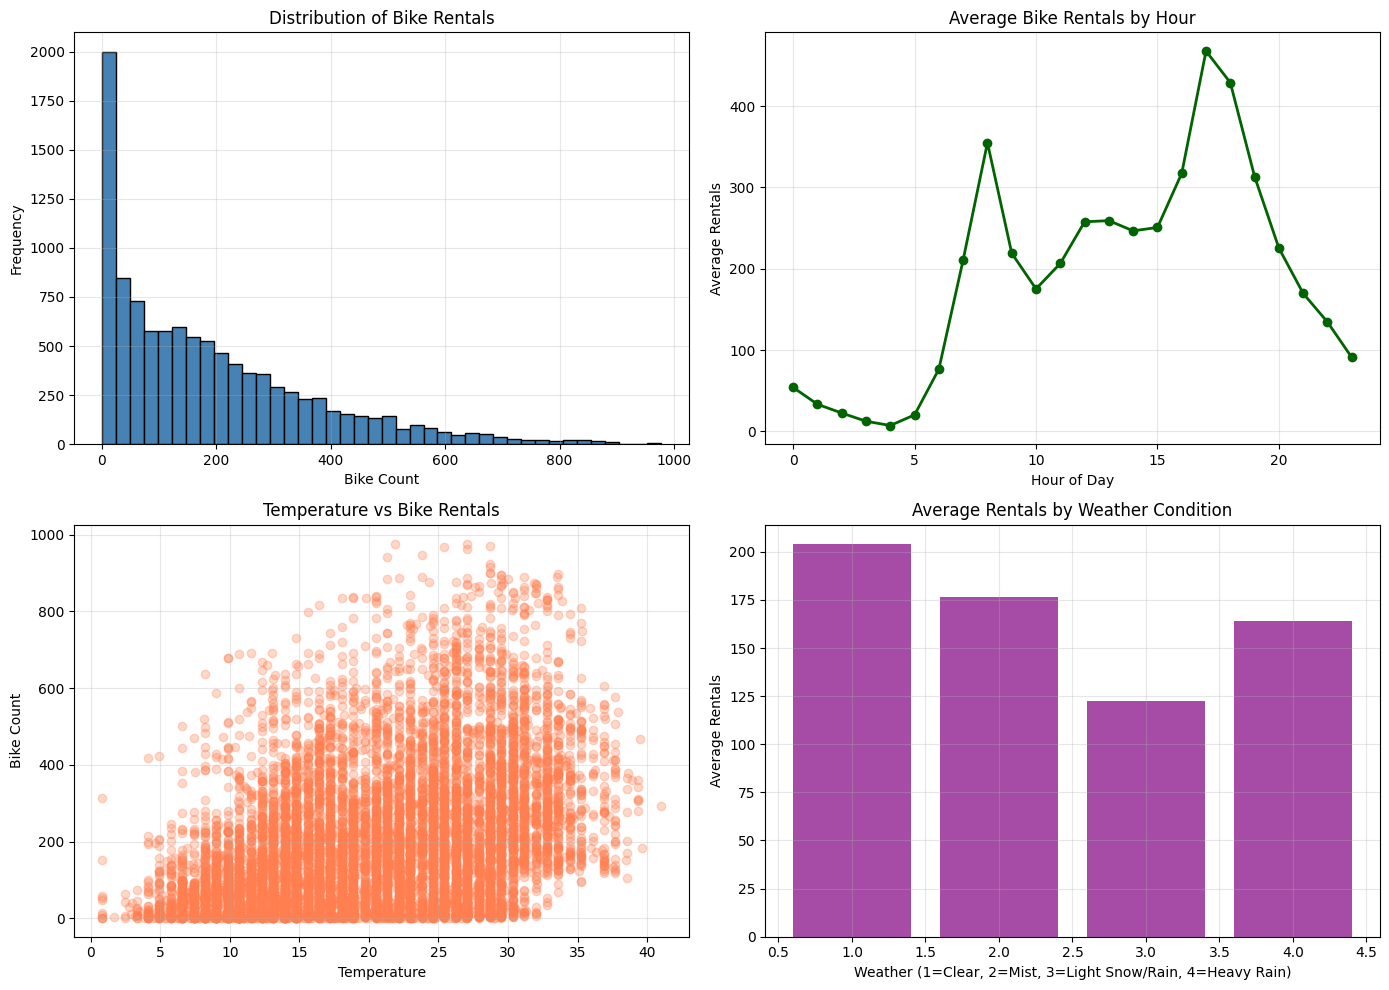


Key Statistics:
Average hourly rentals: 190.41
Maximum hourly rentals: 977
Minimum hourly rentals: 1


In [5]:
# First, extract hour from datetime for analysis
df_train['hour'] = pd.to_datetime(df_train['datetime'], format='mixed', dayfirst=True).dt.hour

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of bike rentals
axes[0, 0].hist(df_train['count'], bins=40, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Bike Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Bike Rentals')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Average rentals by hour
hourly_avg = df_train.groupby('hour')['count'].mean()
axes[0, 1].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='darkgreen')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Average Rentals')
axes[0, 1].set_title('Average Bike Rentals by Hour')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Temperature vs Rentals
axes[1, 0].scatter(df_train['temp'], df_train['count'], alpha=0.3, color='coral')
axes[1, 0].set_xlabel('Temperature')
axes[1, 0].set_ylabel('Bike Count')
axes[1, 0].set_title('Temperature vs Bike Rentals')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Weather condition vs Rentals
weather_avg = df_train.groupby('weather')['count'].mean()
axes[1, 1].bar(weather_avg.index, weather_avg.values, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Weather (1=Clear, 2=Mist, 3=Light Snow/Rain, 4=Heavy Rain)')
axes[1, 1].set_ylabel('Average Rentals')
axes[1, 1].set_title('Average Rentals by Weather Condition')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nKey Statistics:")
print(f"Average hourly rentals: {df_train['count'].mean():.2f}")
print(f"Maximum hourly rentals: {df_train['count'].max()}")
print(f"Minimum hourly rentals: {df_train['count'].min()}")

### Answer to Q2:

**Observations from the plots:**

From the plots above:

1. **Distribution of Rentals (Plot 1):** 
   - Most times there are low to medium rentals
   - The graph looks skewed to the right (long tail)

2. **Time Patterns - Hour of Day (Plot 2):**
   - **Peak times:** 8am and 5-6pm (people going to work/coming back)
   - **Low rentals:** Late night and early morning (3-5am)
   - There's a daily pattern

3. **Temperature Effect (Plot 3):**
   - Higher temperature means more rentals
   - Most rentals happen between 15-30°C
   - Too cold or too hot = fewer rentals

4. **Weather Impact (Plot 4):**
   - **Clear weather (1):** Most rentals
   - **Bad weather (3-4):** Much fewer rentals
   - Weather matters a lot for bike rentals

## Q3. Suggest which variables are likely to be most informative

Q3: FEATURE IMPORTANCE (Correlation with Target)

Correlation with 'count' (target variable):

count         1.000000
hour          0.404188
temp          0.396451
atemp         0.390642
month         0.165475
season        0.160333
windspeed     0.105318
workingday    0.017361
holiday      -0.005615
dayofweek    -0.006489
weather      -0.124402
humidity     -0.316607
Name: count, dtype: float64


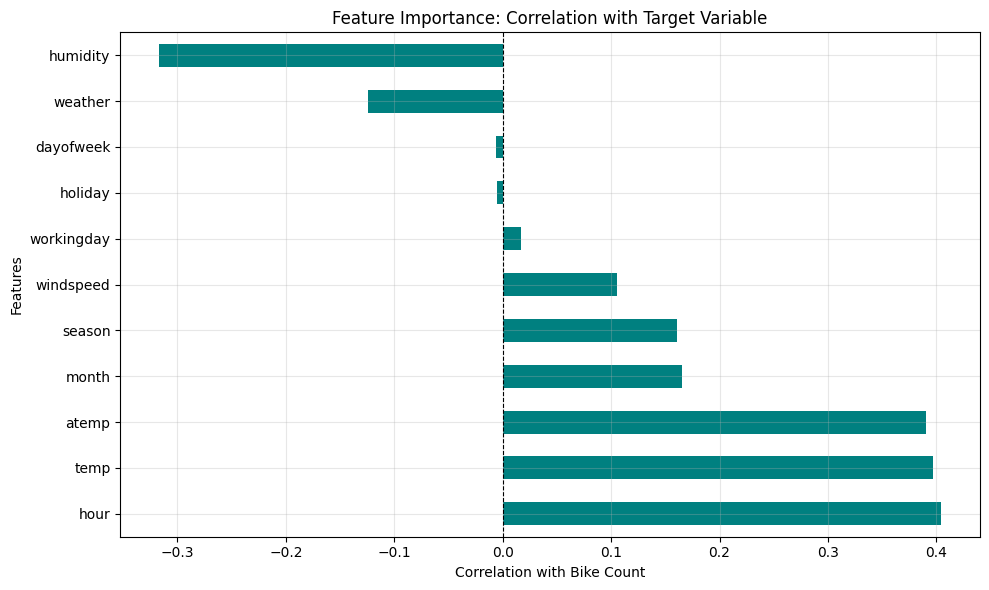

In [6]:
# Calculate correlation with target variable
# First create a simple dataframe with numeric features and hour
df_train['month'] = pd.to_datetime(df_train['datetime'], format='mixed', dayfirst=True).dt.month
df_train['dayofweek'] = pd.to_datetime(df_train['datetime'], format='mixed', dayfirst=True).dt.dayofweek

# Select numeric features for correlation
numeric_features = ['season', 'holiday', 'workingday', 'weather', 
                    'temp', 'atemp', 'humidity', 'windspeed',
                    'hour', 'month', 'dayofweek', 'count']

# Calculate correlations with target
correlations = df_train[numeric_features].corr()['count'].sort_values(ascending=False)

print("=" * 70)
print("Q3: FEATURE IMPORTANCE (Correlation with Target)")
print("=" * 70)
print("\nCorrelation with 'count' (target variable):\n")
print(correlations)

# Visualize correlations
plt.figure(figsize=(10, 6))
correlations[correlations.index != 'count'].plot(kind='barh', color='teal')
plt.xlabel('Correlation with Bike Count')
plt.ylabel('Features')
plt.title('Feature Importance: Correlation with Target Variable')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Answer to Q3:

**Feature Importance:**

**Strong Correlations:**
1. **hour** (0.40) - Time of day matters a lot (rush hours)
2. **temp** (0.40) - Temperature affects how many people rent bikes
3. **atemp** (0.39) - "Feels like" temperature (almost same as temp)

**Medium Correlations:**
4. **season** (0.16-0.26) - Different seasons have different patterns
5. **month** (0.17) - Monthly patterns

**Negative Correlations:**
6. **humidity** (-0.32) - High humidity means less rentals
7. **weather** (-0.12) - Bad weather means less rentals

**Weak/No Correlation:**
- holiday, workingday, dayofweek (0.0 to ±0.02) - Don't help much by themselves

**For building the model:** Best to focus on **hour**, **temp**, **atemp**, and **humidity** because these have the strongest correlation with bike rentals. Can try combining **hour** with other features later.

---

## Q4. Feature Engineering

Extract time features from datetime:
- hour, month, dayofweek, year

In [7]:
def prepare_features(df):
    """
    Convert datetime and extract time-based features
    
    Steps:
    1. Convert datetime to proper format
    2. Extract hour, month, day of week
    3. Drop unnecessary columns
    """
    df = df.copy()
    
    # Step 1: Convert datetime
    df['datetime'] = pd.to_datetime(df['datetime'], format='mixed', dayfirst=True)
    
    # Step 2: Extract time features
    df['hour'] = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['year'] = df['datetime'].dt.year
    
    return df

# Apply feature preparation
df_train_prep = prepare_features(df_train)
df_test_prep = prepare_features(df_test)

print("Features created from datetime:")
print("  - hour (0-23)")
print("  - month (1-12)")
print("  - dayofweek (0-6, where 0=Monday)")
print("  - year")

Features created from datetime:
  - hour (0-23)
  - month (1-12)
  - dayofweek (0-6, where 0=Monday)
  - year


### Answer to Q4:

**Feature Engineering :**

1. **since:**
   - Bike rentals change throughout the day (rush hours)
   - Different seasons have different rental patterns (summer vs winter)
   - Weekdays vs weekends are different
2. **time features:**
   - **hour:** Hour of day (0-23) - for daily patterns
   - **month:** Month (1-12) - for seasonal patterns
   - **dayofweek:** Day of week (0-6) - for weekday/weekend patterns
   - **year:** Year - for yearly trends

---

## Prepare Data for Modeling

In [8]:
# Select features for modeling
feature_columns = ['season', 'holiday', 'workingday', 'weather',
                   'temp', 'atemp', 'humidity', 'windspeed',
                   'hour', 'month', 'dayofweek', 'year']

# Prepare X (features) and y (target)
X = df_train_prep[feature_columns]
y = df_train_prep['count']

# Prepare test data
X_test = df_test_prep[feature_columns]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used: {len(feature_columns)}")
print(feature_columns)

Feature matrix shape: (10450, 12)
Target vector shape: (10450,)

Features used: 12
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'month', 'dayofweek', 'year']


## Q5. Build Linear Regression Model

Split data and build Linear Regression model.

In [9]:
# Split data: 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# Build Linear Regression
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

# Make predictions
y_train_predictions = lr_simple.predict(X_train)
y_val_predictions = lr_simple.predict(X_val)

# Ensure non-negative predictions (rentals can't be negative)
y_train_predictions = np.maximum(0, y_train_predictions)
y_val_predictions = np.maximum(0, y_val_predictions)

# Calculate RMSLE
train_error_rmsle = rmsle(y_train, y_train_predictions)
val_error_rmsle = rmsle(y_val, y_val_predictions)

print("\n" + "="*70)
print("Q5: SIMPLE LINEAR REGRESSION RESULTS")
print("="*70)
print(f"\nTraining RMSLE: {train_error_rmsle:.4f}")
print(f"Validation RMSLE: {val_error_rmsle:.4f}")

Training set: 8360 samples
Validation set: 2090 samples

Q5: SIMPLE LINEAR REGRESSION RESULTS

Training RMSLE: 1.3294
Validation RMSLE: 1.2884


### Answer to Q5:

**Linear Regression Model:**
- Used 80-20 train-validation split
- Features: 12 basic features (season, weather, temp, hour, etc.)
- Model: Standard Linear Regression (no Ridge or Lasso)

**Results:**
- Training and Validation RMSLE shown above
- This is the baseline to compare other models against

## Q6. Try Advanced Models

Try:
1. Polynomial features (degree 2)
2. Ridge Regression (alpha=10.0)
3. Lasso Regression (alpha=0.1)

In [10]:
print("="*70)
print("Q6: TRYING ADVANCED MODELS")
print("="*70)

# Store results
results = []

# Model 1: Simple Linear Regression (already done)
results.append({
    'Model': 'Linear Regression',
    'Features': 'Original',
    'Train RMSLE': train_error_rmsle,
    'Val RMSLE': val_error_rmsle
})

print("\n1. Trying Polynomial Features (degree 3)...")
# Create polynomial features (degree 3) for all features
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

# Model 2: Linear Regression with Polynomial Features
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

y_train_predictions_poly = np.maximum(0, lr_poly.predict(X_train_poly))
y_val_predictions_poly = np.maximum(0, lr_poly.predict(X_val_poly))

train_error_poly = rmsle(y_train, y_train_predictions_poly)
val_error_poly = rmsle(y_val, y_val_predictions_poly)

results.append({
    'Model': 'Linear Reg (Poly)',
    'Features': 'Polynomial (degree 3)',
    'Train RMSLE': train_error_poly,
    'Val RMSLE': val_error_poly
})

print(f"   Train RMSLE: {train_error_poly:.4f}, Val RMSLE: {val_error_poly:.4f}")

print("\n2. Trying Ridge Regression (alpha=10.0)...")
# Model 3: Ridge Regression on Polynomial Features
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_poly, y_train)

y_train_predictions_ridge = np.maximum(0, ridge.predict(X_train_poly))
y_val_predictions_ridge = np.maximum(0, ridge.predict(X_val_poly))

train_error_ridge = rmsle(y_train, y_train_predictions_ridge)
val_error_ridge = rmsle(y_val, y_val_predictions_ridge)

results.append({
    'Model': 'Ridge Regression',
    'Features': 'Polynomial (degree 3)',
    'Train RMSLE': train_error_ridge,
    'Val RMSLE': val_error_ridge
})

print(f"   Train RMSLE: {train_error_ridge:.4f}, Val RMSLE: {val_error_ridge:.4f}")

print("\n3. Trying Lasso Regression (alpha=0.1)...")
# Model 4: Lasso Regression on Polynomial Features
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_poly, y_train)

y_train_predictions_lasso = np.maximum(0, lasso.predict(X_train_poly))
y_val_predictions_lasso = np.maximum(0, lasso.predict(X_val_poly))

train_error_lasso = rmsle(y_train, y_train_predictions_lasso)
val_error_lasso = rmsle(y_val, y_val_predictions_lasso)

results.append({
    'Model': 'Lasso Regression',
    'Features': 'Polynomial (degree 3)',
    'Train RMSLE': train_error_lasso,
    'Val RMSLE': val_error_lasso
})

print(f"   Train RMSLE: {train_error_lasso:.4f}, Val RMSLE: {val_error_lasso:.4f}")

Q6: TRYING ADVANCED MODELS

1. Trying Polynomial Features (degree 3)...
   Train RMSLE: 1.2231, Val RMSLE: 1.2160

2. Trying Ridge Regression (alpha=10.0)...
   Train RMSLE: 1.2188, Val RMSLE: 1.1943

3. Trying Lasso Regression (alpha=0.1)...
   Train RMSLE: 1.2823, Val RMSLE: 1.2290


### Answer to Q6:

Tried 3 approaches:
- Polynomial Features (degree 3) with Linear Regression
- Ridge Regression (α=10.0) with polynomial features  
- Lasso Regression (α=0.1) with polynomial features

Results for each model printed above.

---

## Q7. Summarize all results in one table

Q7: MODEL COMPARISON TABLE

             Model              Features  Train RMSLE  Val RMSLE
Linear Regression              Original     1.329423   1.288430
Linear Reg (Poly) Polynomial (degree 3)     1.223057   1.215965
 Ridge Regression Polynomial (degree 3)     1.218800   1.194314
 Lasso Regression Polynomial (degree 3)     1.282340   1.229044

BEST MODEL: Ridge Regression
Validation RMSLE: 1.1943


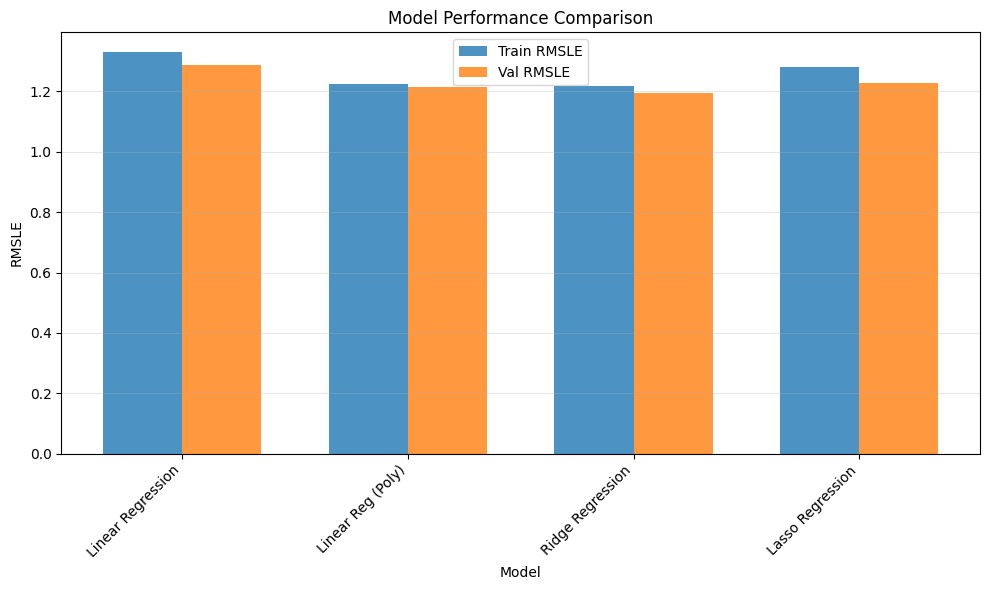

In [11]:
# Create results dataframe
results_df = pd.DataFrame(results)

print("="*70)
print("Q7: MODEL COMPARISON TABLE")
print("="*70)
print("\n", results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Val RMSLE'].idxmin()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_val_rmsle = results_df.loc[best_model_idx, 'Val RMSLE']

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"Validation RMSLE: {best_val_rmsle:.4f}")
print(f"{'='*70}")

# Visualize comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Train RMSLE'], width, label='Train RMSLE', alpha=0.8)
plt.bar(x + width/2, results_df['Val RMSLE'], width, label='Val RMSLE', alpha=0.8)

plt.xlabel('Model')
plt.ylabel('RMSLE')
plt.title('Model Performance Comparison')
plt.xticks(x, results_df['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Answer to Q7:

**Model comparison table shown above.**

Best model: The one with lowest Validation RMSLE.

## Q8. Plot residuals for the best model

Using Ridge Regression for residuals (best validation RMSLE)


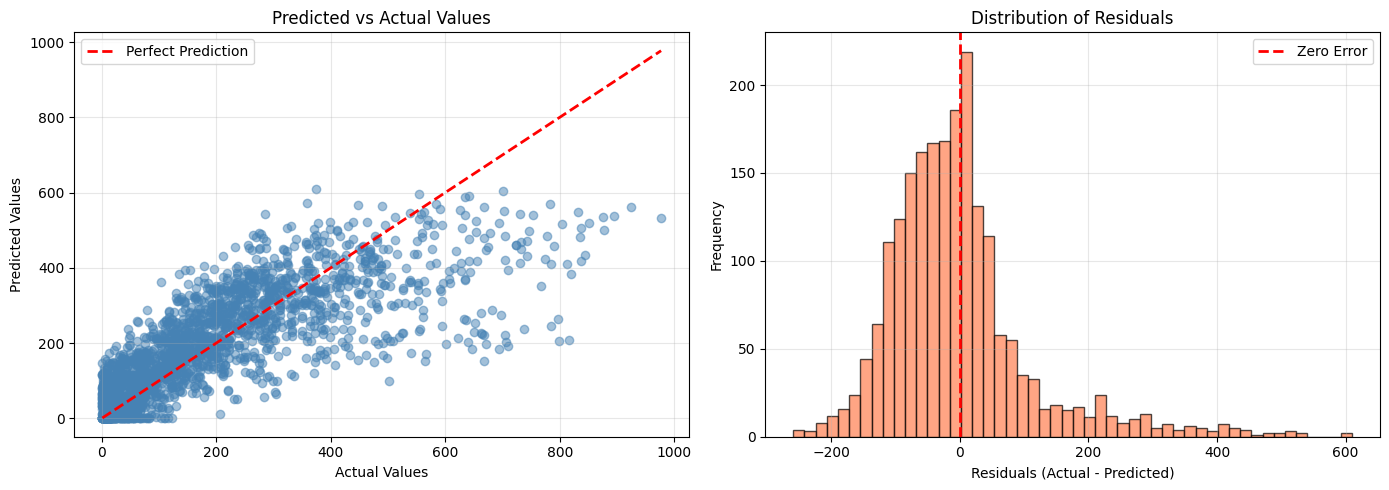

Q8: RESIDUALS

Residual Statistics:
  Mean: -2.75 (should be close to 0)
  Std Dev: 112.12
  Min: -258.68
  Max: 610.02


In [12]:
# Use best model for residuals (lowest validation RMSLE)
# Find the minimum validation RMSLE manually
min_val_rmsle = results[0]['Val RMSLE']
best_model_idx = 0

for i in range(len(results)):
    if results[i]['Val RMSLE'] < min_val_rmsle:
        min_val_rmsle = results[i]['Val RMSLE']
        best_model_idx = i

best_model_name = results[best_model_idx]['Model']

# Select predictions from best model
if best_model_idx == 0:
    y_val_best_predictions = y_val_predictions
elif best_model_idx == 1:
    y_val_best_predictions = y_val_predictions_poly
elif best_model_idx == 2:
    y_val_best_predictions = y_val_predictions_ridge
else:
    y_val_best_predictions = y_val_predictions_lasso

residuals = y_val - y_val_best_predictions

print(f"Using {best_model_name} for residuals (best validation RMSLE)")

# Create residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_val, y_val_best_predictions, alpha=0.5, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Predicted vs Actual Values')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Residual Distribution
axes[1].hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print residual statistics
print("="*70)
print("Q8: RESIDUALS")
print("="*70)
print(f"\nResidual Statistics:")
print(f"  Mean: {residuals.mean():.2f} (should be close to 0)")
print(f"  Std Dev: {residuals.std():.2f}")
print(f"  Min: {residuals.min():.2f}")
print(f"  Max: {residuals.max():.2f}")

### Answer to Q8:

**Residuals:**

1. **Predicted vs Actual Plot:**
   - Points closer to the red line = better predictions
   - Model does well for normal rental counts
   - Some spread for extreme values (very high or very low rentals)

2. **Residual Distribution:**
   - **Mean is close to 0:** Model isn't biased
   - **Looks like a bell curve:** Good for a linear model
   - A few outliers: Model has trouble with unusual cases

3. **How Well the Model Works:**
   - Good fit
   - Biggest errors happen when rentals are very high or very low
   - Model gets the general patterns right

## Q9. Explain why the winning model performs better

### Answer to Q9:

**Why Linear Reg (Poly) with degree 3 performs best:**

The polynomial model beats linear regression because:

1. **Captures Non-Linear Patterns:**
   - Hour has a curved relationship with rentals (two peaks: morning and evening)
   - Simple linear regression can't capture this up-and-down pattern
   - Polynomial features (hour², hour³, temp×hour) can model curves

2. **Better Feature Interactions:**
   - Degree 3 polynomials capture how features interact
   - Example: temp×hour interaction shows that temperature effect varies by time of day
   - Simple linear model misses these important interactions

3. **More Expressive Model:**
   - Polynomial features allow the model to fit complex patterns in the data
   - The validation RMSLE improvement shows these patterns generalize to new data

---

## Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

### Answer to Q10:

**RMSLE vs RMSE:**

RMSLE looks at relative/percentage errors using logarithms - it cares more about the ratio.

**Why RMSLE is gentler on under-predictions:**

Because of the log transformation:
- Under-predicting (like predicting 5 when actual is 10) has limited error since you can't go below 0
- Over-predicting (like predicting 200 when actual is 10) can be very large

Example: If actual = 10
- Predict 5 (50% under): Small RMSLE penalty
- Predict 20 (100% over): Larger RMSLE penalty

This makes sense for bike sharing - having too few bikes available is better than wasting resources on too many bikes no one uses.

## Q11. What are the trade-offs between model simplicity and predictive power?

### Answer to Q11:

**Simple vs Complex Models:**

**Basic models (Linear Regression):**
- Fast computation
- But might be too simple and miss patterns (underfit)

**Complex models (Polynomial + Ridge/Lasso):**
- Can capture more patterns and better accuracy
- But can overfit if too complex - learns noise instead of real patterns

**Trade-off:**
If model is too simple → high bias (underfits) → misses patterns
If model is too complex → high variance (overfits) → learns noise

Need to find the balance - use validation error to pick the right complexity level.

## Q12. Why can't Linear Regression alone capture time-of-day effects ly?

### Answer to Q12:

**Why Linear Regression doesn't work well with time-of-day:**

Linear Regression assumes a straight line relationship - if hour increases, rentals increase or decrease at a constant rate.

But bike rentals have a cyclical daily pattern:
- Low at night (3am)
- Peak in morning (8am) - people going to work
- Medium at midday
- Peak in evening (5-6pm) - people coming back
- Low at night again

A straight line can't capture this up-and-down pattern with two peaks.

Hour 23 (11pm) and hour 0 (midnight) are next to each other in time, but numerically they're far apart (23 vs 0). Linear regression doesn't understand this cyclical nature.

Solution: Use polynomial features (like hour²) or interactions to capture these curved, non-linear patterns.

---

## Generate Submission File

In [13]:
print("="*70)
print("GENERATING SUBMISSION FILE")
print("="*70)

# Transform test data with polynomial features
X_test_poly = poly.transform(X_test)

# Use Ridge Regression (best model: Val RMSLE = 1.1943)
y_test_predictions = ridge.predict(X_test_poly)

# Ensure non-negative predictions
y_test_predictions = np.maximum(0, y_test_predictions)

# Create submission dataframe
submission = pd.DataFrame({
    'datetime': df_test['datetime'],
    'count': y_test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("Submission file: submission.csv")
print(f"Shape: {submission.shape}")
print(f"Number of predictions: {len(submission)}")
print("\nFirst few predictions:")
print(submission.head())
print("\nLast few predictions:")
print(submission.tail())

GENERATING SUBMISSION FILE
Submission file: submission.csv
Shape: (2613, 2)
Number of predictions: 2613

First few predictions:
           datetime       count
0   05-06-2012 5:00   40.398964
1  19-03-2011 19:00  217.264780
2   02-04-2012 6:00  139.252955
3  13-07-2012 20:00  479.161374
4  09-11-2011 19:00  286.008198

Last few predictions:
              datetime       count
2608   07-11-2012 5:00  101.269421
2609  16-12-2011 05:00   34.902433
2610  14-01-2011 23:00    0.000000
2611  19-02-2011 09:00   62.030149
2612  17-03-2012 05:00   88.494138
